# Report CTD transect on 12 Jan 2026

Includes 12 CTD profiles taking at 11 locations along N-S transect (2 profiles at P06)

In [52]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\figures'))
from functions_figures import array_bands, get_cmap_discrete, compute_logmedian_list
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\ctd'))
#from functions_ctd import thorpe_scale
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\general_functions'))
from general_functions import read_netCDF_xr, datenum2timestamp
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'  # or any installed font
plt.close('all')


%matplotlib widget 

### Specify if using Renku or not:

In [3]:
using_Renku = False

In [4]:
if using_Renku:
    datafolder=os.path.join('..','..','..','..','data-lakezug')   
else:
    datafolder=os.path.join('..','..','..','data')
    # For interactive plots in Jupyter Notebook 
    %matplotlib widget     

Parameters

In [5]:
#%% Specify field campaign here:
campaign_name='20260112'
categories=['VMPS','VMPC','VMPW'] # Among profile names (CTD)
colcat=[[50/255,100/255,214/255],[1, 0.4, 0.15],[0.1, 0.6, 0.3]]
colcat_light=[[140/255,170/255,230/255],[1, 0.75, 0.6],[0.5,0.8,0.5]]

data_folder_rel_CTD=os.path.join(datafolder,'CTD',campaign_name)
# CTD transect:
fileCTD='CTD_transect_'+campaign_name+'.nc'
plot_transect=True

# Individual profiles:
fileCTDprof=[f for f in os.listdir(os.path.join(data_folder_rel_CTD,'Level2B')) if f.endswith('.nc')]
colCTD=plt.get_cmap('viridis', len(fileCTDprof))

savefig=True

Load the data

In [6]:
# Bathymetry:
data_bathy=read_netCDF_xr(os.path.join('..','..','..','data','Bathymetry','Level2','bathymetry_Zug_10m.nc'))

#%% CTD transect:
if plot_transect:
    dataprof_CTDt=read_netCDF_xr(os.path.join(data_folder_rel_CTD,'Level3',fileCTD))
    datetime_CTDt=pd.to_datetime(dataprof_CTDt.time.values, unit='s')
    profnames_CTDt=list(dataprof_CTDt.profnames.values)
    indcat_CTDt=[np.where(dataprof_CTDt.profnames.values==catname)[0] for catname in categories]
    colCTDt=plt.get_cmap('viridis', len(dataprof_CTDt.time))

#%% CTD profiles:
dataprof_CTD_list=[]
datetime_CTD=[]
profnames_CTD=[]
xcoord_CTD=[]
ycoord_CTD=[]
for kf in range(len(fileCTDprof)):     
    dataprof_CTD_list.append(read_netCDF_xr(os.path.join(data_folder_rel_CTD,'Level2B',fileCTDprof[kf])))
    datetime_CTD.append(pd.to_datetime(dataprof_CTD_list[kf].time.values[0], unit='s'))
    profnames_CTD.append(dataprof_CTD_list[kf].attrs['Profile name'])
    xcoord_CTD.append(int(dataprof_CTD_list[kf].attrs['X Coordinate (CH1903)']))
    ycoord_CTD.append(int(dataprof_CTD_list[kf].attrs['Y Coordinate (CH1903)']))

indcat_CTD=[np.where(np.array(profnames_CTD)==catname)[0] for catname in categories]
indcat_withCTD=list(np.where([len(i)>0 for i in indcat_CTD])[0])

Plot the map

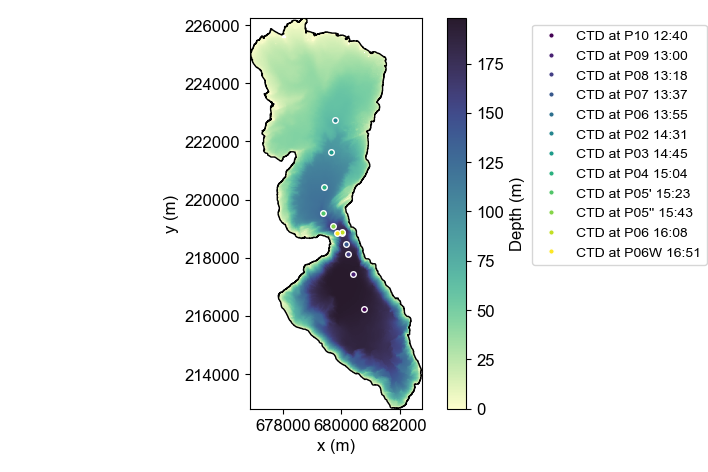

In [42]:
fig,ax = plt.subplots(1,1,figsize=(18 / 2.54, 12 / 2.54))  # Convert from cm to inches

hp=ax.pcolormesh(data_bathy.x-2e6, data_bathy.y-1e6,data_bathy.depth,vmin=0,vmax=np.nanmax(data_bathy.depth),cmap="cmo.deep")
ax.plot(data_bathy.x_contour-2e6, data_bathy.y_contour-1e6, color='k', linewidth=1)
ax.set_aspect("equal")
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
cb = fig.colorbar(hp, ax=ax)
cb.set_label('Depth (m)')

# Add the CTD profiles:
indchrono_CTD=np.argsort(np.array(datetime_CTD))
counter=0
for kCTD in indchrono_CTD:
    ax.plot(xcoord_CTD[kCTD], ycoord_CTD[kCTD], marker='o', linestyle='', color=colCTD(counter), markersize=4, 
            markeredgecolor='w',markeredgewidth=1,label='CTD at '+profnames_CTD[kCTD]+' '+str(datetime_CTD[kCTD].strftime('%H:%M')))
    counter+=1
# if plot_transect:
#     for kCTD in range(len(dataprof_CTDt.time)):
#         ax.plot(dataprof_CTDt.xcoord[kCTD], dataprof_CTDt.ycoord[kCTD], marker='s', linestyle='', color=colCTDt(kCTD), markersize=4, 
#                 markeredgecolor='w',markeredgewidth=1,label=dataprof_CTDt.profnames.values[kCTD]+' '+str(datetime_CTDt[kCTD].strftime('%H:%M')))
ax.legend(loc='upper left',bbox_to_anchor=(1.6, 1), fontsize=10)

fig.set_tight_layout(True)

Plot individual CTD profiles

C:\Users\tdoda\AppData\Local\Temp\ipykernel_35292\4024021127.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots(1,4,figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


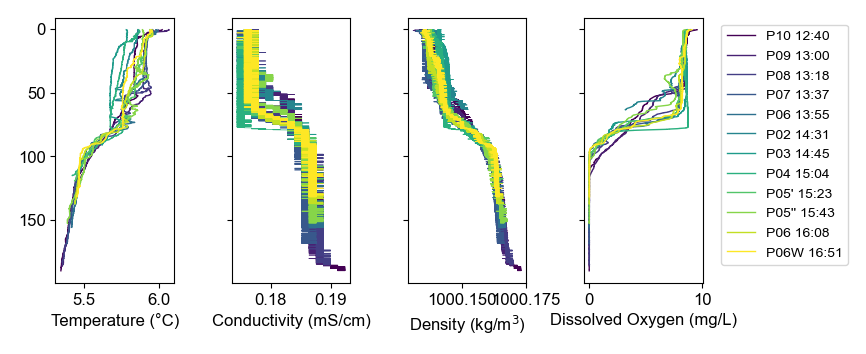

In [43]:
fig,ax = plt.subplots(1,4,figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

# Plot CTD profiles
counter=0
for kprof in indchrono_CTD:
    ax[0].plot(dataprof_CTD_list[kprof]["Temp"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(counter), linewidth=1)
    ax[1].plot(dataprof_CTD_list[kprof]["Cond"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(counter), linewidth=0.5)
    ax[2].plot(dataprof_CTD_list[kprof]["rho"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(counter), linewidth=0.5)
    ax[3].plot(dataprof_CTD_list[kprof]["DO_mg"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(counter), linewidth=1,label=profnames_CTD[kprof]+' '+str(datetime_CTD[kprof].strftime('%H:%M')))
    counter+=1 
ax[0].set_xlabel('Temperature (°C)')
ax[1].set_xlabel('Conductivity (mS/cm)')
ax[2].set_xlabel('Density (kg/m$^3$)')
ax[2].ticklabel_format(useOffset=False, style='plain', axis='x')
ax[3].set_xlabel('Dissolved Oxygen (mg/L)')
ax[0].invert_yaxis()  # Reverse the y-axis 

ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_profiles_'+campaign_name+'.png',dpi=400)
    fig.savefig('CTD_profiles_'+campaign_name+'.svg',dpi=1000)

    


Plot CTD profiles from transect

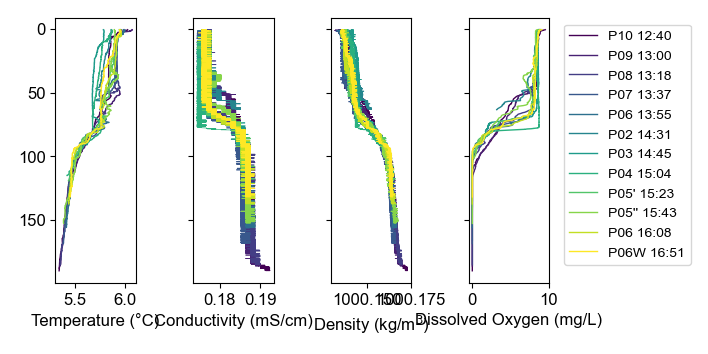

In [70]:

if plot_transect:

    fig,ax = plt.subplots(1,4,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

    # Plot CTD profiles
    for kprof in range(len(dataprof_CTDt.time)):
        ax[0].plot(dataprof_CTDt["temp"].values[:,kprof], dataprof_CTDt["depth"].values, color=colCTDt(kprof), linewidth=1)
        ax[1].plot(dataprof_CTDt["cond"].values[:,kprof], dataprof_CTDt["depth"].values, color=colCTDt(kprof), linewidth=0.5)
        ax[2].plot(dataprof_CTDt["rho"].values[:,kprof], dataprof_CTDt["depth"].values, color=colCTDt(kprof), linewidth=0.5)
        ax[3].plot(dataprof_CTDt["DO"].values[:,kprof], dataprof_CTDt["depth"].values, color=colCTDt(kprof), linewidth=1,label=profnames_CTDt[kprof]+' '+str(datetime_CTDt[kprof].strftime('%H:%M')))
        
    ax[0].set_xlabel('Temperature (°C)')
    ax[1].set_xlabel('Conductivity (mS/cm)')
    ax[2].set_xlabel('Density (kg/m$^3$)')
    ax[2].ticklabel_format(useOffset=False, style='plain', axis='x')
    ax[3].set_xlabel('Dissolved Oxygen (mg/L)')
    ax[0].invert_yaxis()  # Reverse the y-axis 

    ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)


    fig.set_tight_layout(True)

    # Save figure

    if savefig:
        fig.savefig('CTD_profiles_transect_'+campaign_name+'.png',dpi=400)
        fig.savefig('CTD_profiles_transect_'+campaign_name+'.svg',dpi=1000)

    


Plot temperature and oxygen displacements

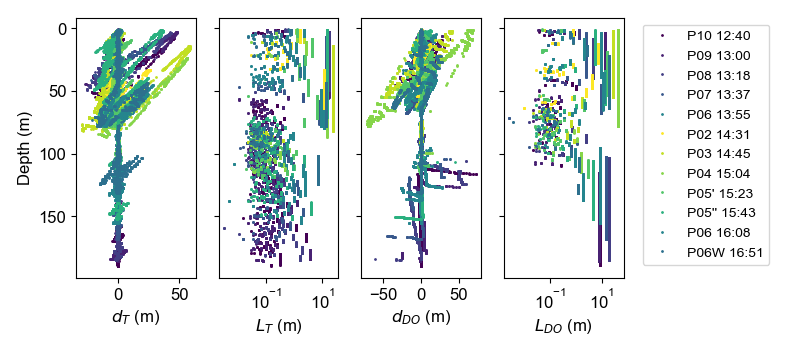

In [50]:
# Reorder from N to S
ind_NS=np.argsort(ycoord_CTD)
profnames_NS=np.array([profnames_CTD[i] for i in ind_NS])

fig,ax = plt.subplots(1,4,figsize=(20 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

# Plot CTD profiles
for kprof in indchrono_CTD:
    ind_col=np.where(profnames_NS==profnames_CTD[kprof])[0][0]
    if profnames_CTD[kprof] in [""]:
        colprof='r'
    else:
        colprof=colCTD(ind_col)
    ax[0].plot(dataprof_CTD_list[kprof]["thorpe_disp"].values, dataprof_CTD_list[kprof]["depth"].values, '.',markersize=2,color=colprof)
    ax[1].plot(dataprof_CTD_list[kprof]["Lt"].values, dataprof_CTD_list[kprof]["depth"].values, '.',markersize=2,color=colprof)
    ax[2].plot(dataprof_CTD_list[kprof]["DO_disp"].values, dataprof_CTD_list[kprof]["depth"].values, '.',markersize=2,color=colprof)
    ax[3].plot(dataprof_CTD_list[kprof]["Lt_DO"].values, dataprof_CTD_list[kprof]["depth"].values, '.',markersize=2,color=colprof,
    label=profnames_CTD[kprof]+' '+str(datetime_CTD[kprof].strftime('%H:%M')))
   
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel('$d_{T}$ (m)')
ax[1].set_xlabel('$L_{T}$ (m)')
ax[1].set_xscale('log')
ax[2].set_xlabel('$d_{DO}$ (m)')
ax[3].set_xlabel('$L_{DO}$ (m)')
ax[3].set_xscale('log')
ax[0].invert_yaxis()  # Reverse the y-axis 

ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_displacements_'+campaign_name+'.png',dpi=400)
    fig.savefig('CTD_displacements_'+campaign_name+'.svg',dpi=1000)

Plot displacements from the interpolated grid

In [63]:
# Reorder from N to S
ind_NS=np.argsort(dataprof_CTDt.ycoord.data)

dx=200 # Band width [m]
ymat,Ltmat=array_bands(dataprof_CTDt.ycoord.data[ind_NS],dataprof_CTDt.Lt.data[:,ind_NS],dx)
_,LDOmat=array_bands(dataprof_CTDt.ycoord.data[ind_NS],dataprof_CTDt.Lt_DO.data[:,ind_NS],dx)
_,Tmat=array_bands(dataprof_CTDt.ycoord.data[ind_NS],dataprof_CTDt.temp.data[:,ind_NS],dx)

mask_prof = np.isnan(Tmat) # =true if no profile

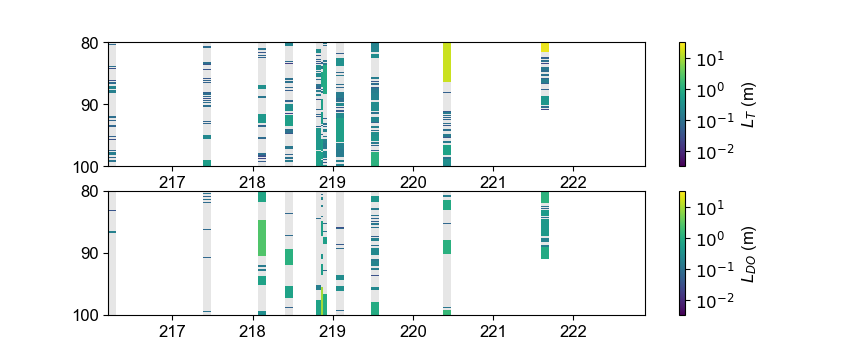

In [69]:
fig,ax = plt.subplots(2,1,figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches
ax[0].pcolormesh(ymat/1000,dataprof_CTDt.depth.data,np.ma.masked_where(mask_prof,~mask_prof),cmap=mcolors.ListedColormap(["0.9"]))
hLT=ax[0].pcolormesh(ymat/1000,dataprof_CTDt.depth.data,np.log10(Ltmat),rasterized=True,vmin=-2.5,vmax=1.5)
ax[1].pcolormesh(ymat/1000,dataprof_CTDt.depth.data,np.ma.masked_where(mask_prof,~mask_prof),cmap=mcolors.ListedColormap(["0.9"]))
hLDO=ax[1].pcolormesh(ymat/1000,dataprof_CTDt.depth.data,np.log10(LDOmat),rasterized=True,vmin=-2.5,vmax=1.5,)

ax[0].set_ylim(80,100)
ax[0].invert_yaxis()
cb_LT=fig.colorbar(hLT)
cb_LT.set_ticks([-2, -1, 0,1])
cb_LT.set_ticklabels([r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$',r'$10^{1}$'])
cb_LT.set_label('$L_T$ (m)')
cb_LDO=fig.colorbar(hLDO)
cb_LDO.set_ticks([-2, -1, 0,1])
cb_LDO.set_ticklabels([r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$',r'$10^{1}$'])
cb_LDO.set_label('$L_{DO}$ (m)')